# How are in-demand skills trending for Data Analysts?

## Methodology

1. Aggregate skill counts monthly  
2. Re-analyze based on percentage of total jobs  
3. Plot the monthly skill demand  

In [71]:
# Importing libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [81]:
df_DA_IND = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()

In [82]:
df_DA_IND['job_posted_month_no'] = df_DA_IND['job_posted_date'].dt.month

In [83]:
df_DA_IND_explode = df_DA_IND.explode('job_skills')

In [84]:
df_DA_IND_pivot = df_DA_IND_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_IND_pivot.loc['Total'] = df_DA_IND_pivot.sum()

df_DA_IND_pivot = df_DA_IND_pivot[df_DA_IND_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_IND_pivot = df_DA_IND_pivot.drop('Total')

In [85]:
DA_totals = df_DA_IND.groupby('job_posted_month_no').size()

In [86]:
df_DA_IND_percent = df_DA_IND_pivot.div(DA_totals / 100, axis=0)

In [87]:
# changes month number to month name
df_DA_IND_percent = df_DA_IND_percent.reset_index()
df_DA_IND_percent['job_posted_month'] = df_DA_IND_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_IND_percent = df_DA_IND_percent.set_index('job_posted_month')
df_DA_IND_percent = df_DA_IND_percent.drop(columns='job_posted_month_no')

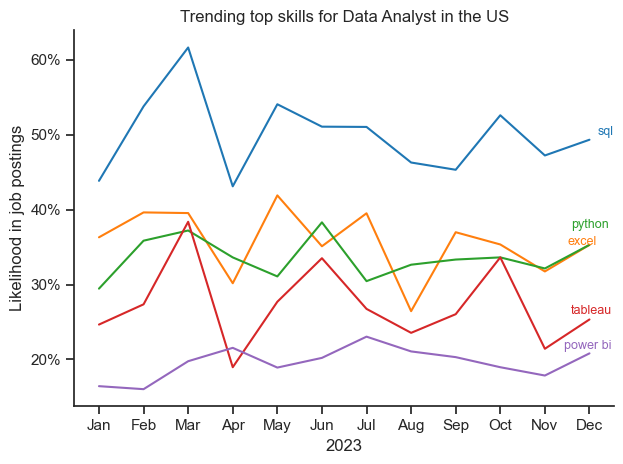

In [95]:
# pip install adjustText
from adjustText import adjust_text

df_plot = df_DA_IND_percent.iloc[:, :5]
fig, ax = plt.subplots()
sns.lineplot(data=df_plot, dashes=False, palette='tab10', ax=ax)
sns.despine()

plt.title('Trending top skills for Data Analyst in the US')
plt.ylabel('Likelihood in job postings')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter())

colors = sns.color_palette('tab10', n_colors=5)
texts = []
for i, col in enumerate(df_plot.columns):
    texts.append(ax.text(11.2, df_plot.iloc[-1, i], col, fontsize=9, color=colors[i]))

# Automatically separates overlapping labels
adjust_text(texts, only_move={'points': 'y', 'texts': 'y'})

plt.tight_layout()
plt.show()